In [1]:
# ── Cell 1: Imports + paths ───────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde

_BASE = (
    '/Users/farjam/Library/CloudStorage'
    '/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP'
)
PLOTS_ROOT = Path(_BASE) / 'Plots'
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

print('Imports OK')
print(f'Plots → {PLOTS_ROOT}')

Imports OK
Plots → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots


In [5]:
# ── Cell 2: Age data + summary statistics ────────────────────────────────────
# Source: HELIOS_Participant_Sheet_Part_B_Session_1

AGE_DATA = {
    '1001': 25.0, '1002': 43.0, '1004': 33.0, '1005': 50.0, '1007': 31.0,
    '1008': 25.0, '1010': 26.0, '1011': 37.0, '1014': 23.0, '1016': 36.0,
    '1017': 46.0, '1018': 25.0, '1020': 29.0, '1021': 28.0, '1023': 46.0,
    '1024': 24.0, '1026': 25.0, '1028': 62.0, '1034': 60.0, '1038': 45.0,
    '1039': 63.0, '1041': 49.0, '1042': 39.0, '1044': 62.0, '1046': 61.0,
    '1052': 53.0, '2002': 62.0, '2006': 25.0, '2009': 49.0, '2017': 31.0,
    '2020': 43.0, '2023': 49.0, '2026': 47.0, '2028': 29.0, '2029': 50.0,
    '2037': 45.0, '3001': 54.0, '3005': 39.0, '3006': 33.0, '3007': 41.0,
    '3008': 32.0, '3011': 31.0, '3014': 34.0, '3016': 44.0, '3027': 72.0,
    '3030': 54.0, '3034': 48.0, '3039': 34.0, '3041': 35.0,
}

ages = np.array(list(AGE_DATA.values()))
n          = len(ages)
mean_age   = np.mean(ages)
sd_age     = np.std(ages, ddof=1)
median_age = np.median(ages)
min_age    = ages.min()
max_age    = ages.max()

# Age groups for Panel C
young  = (ages <= 40).sum()   # ≤ 40 years
older  = (ages >  40).sum()   # > 40 years

print('=' * 50)
print(f'  N participants : {n}')
print(f'  Mean age       : {mean_age:.1f} years')
print(f'  SD             : {sd_age:.1f} years')
print(f'  Median         : {median_age:.1f} years')
print(f'  Range          : {min_age:.0f} – {max_age:.0f} years')
print(f'  ≤ 40 years     : {young} participants')
print(f'  > 40 years     : {older} participants')
print('=' * 50)

  N participants : 49
  Mean age       : 41.4 years
  SD             : 12.8 years
  Median         : 41.0 years
  Range          : 23 – 72 years
  ≤ 40 years     : 24 participants
  > 40 years     : 25 participants


/var/folders/_t/52p8xpgs1gdctzqmjjcqm0zm0000gn/T/ipykernel_75204/3906730603.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/age_distribution.png
Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/age_distribution.pdf


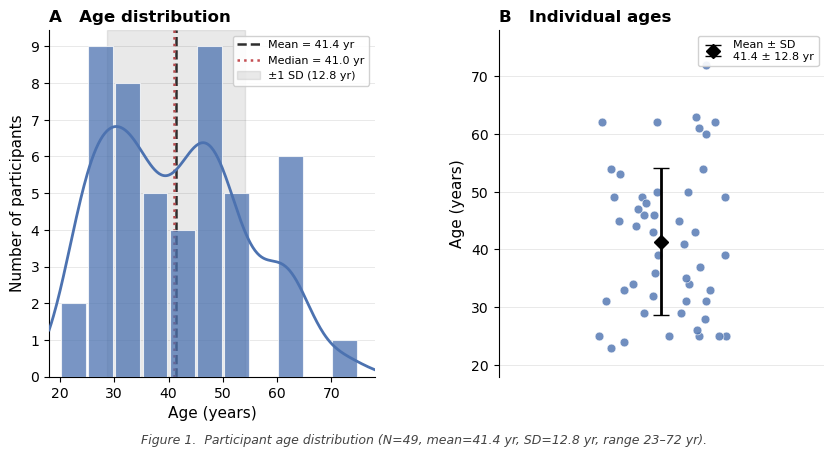

In [8]:
# ── Cell 3: Two-panel figure + save ─────────────────────────────────────────
#
# Panel A — Histogram with KDE overlay, mean/median lines, ±1 SD shading
# Panel B — Strip plot (one dot per participant) with mean ± SD error bar

C_BAR    = '#4C72B0'
C_LINE   = '#2d2d2d'
C_MEDIAN = '#C44E52'

fig = plt.figure(figsize=(10, 4.5))
gs  = GridSpec(1, 2, figure=fig, wspace=0.38)

# ── Panel A: Histogram + KDE ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
bins = np.arange(20, 80, 5)

for i in range(len(bins) - 1):
    mask  = (ages >= bins[i]) & (ages < bins[i + 1])
    count = mask.sum()
    ax1.bar(bins[i] + 2.5, count, width=4.6,
            color=C_BAR, edgecolor='white', linewidth=0.8,
            alpha=0.75, zorder=3)

kde   = gaussian_kde(ages, bw_method=0.35)
x_kde = np.linspace(18, 78, 300)
y_kde = kde(x_kde) * n * 5
ax1.plot(x_kde, y_kde, color=C_BAR, lw=2, zorder=4)

ax1.axvline(mean_age,   color=C_LINE,   lw=1.8, ls='--',
            label=f'Mean = {mean_age:.1f} yr')
ax1.axvline(median_age, color=C_MEDIAN, lw=1.8, ls=':',
            label=f'Median = {median_age:.1f} yr')
ax1.axvspan(mean_age - sd_age, mean_age + sd_age,
            alpha=0.10, color=C_LINE, zorder=2,
            label=f'±1 SD ({sd_age:.1f} yr)')

ax1.legend(fontsize=8, framealpha=0.9)
ax1.set_xlabel('Age (years)', fontsize=11)
ax1.set_ylabel('Number of participants', fontsize=11)
ax1.set_title('A   Age distribution', fontsize=12, fontweight='bold', loc='left')
ax1.set_xlim(18, 78)
ax1.set_xticks(np.arange(20, 80, 10))
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', lw=0.5, alpha=0.4, zorder=0)

# ── Panel B: Strip plot ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
rng    = np.random.default_rng(42)
jitter = rng.uniform(-0.25, 0.25, size=n)

ax2.scatter(np.ones(n) + jitter, ages,
            color=C_BAR, s=40, alpha=0.8,
            edgecolors='white', linewidths=0.5, zorder=3)
ax2.errorbar(1, mean_age, yerr=sd_age,
             fmt='D', color='black', ms=7, lw=2, capsize=6, zorder=5,
             label=f'Mean ± SD\n{mean_age:.1f} ± {sd_age:.1f} yr')

ax2.set_xlim(0.4, 1.6)
ax2.set_ylim(18, 78)
ax2.set_yticks(np.arange(20, 80, 10))
ax2.set_ylabel('Age (years)', fontsize=11)
ax2.set_title('B   Individual ages', fontsize=12, fontweight='bold', loc='left')
ax2.set_xticks([])
ax2.legend(fontsize=8, framealpha=0.9, loc='upper right')
ax2.spines[['top', 'right', 'bottom']].set_visible(False)
ax2.grid(axis='y', lw=0.5, alpha=0.4, zorder=0)

# ── Caption + save ────────────────────────────────────────────────────────────
fig.text(
    0.5, -0.04,
    f'Figure 1.  Participant age distribution '
    f'(N={n}, mean={mean_age:.1f} yr, SD={sd_age:.1f} yr, '
    f'range {min_age:.0f}–{max_age:.0f} yr).',
    ha='center', fontsize=9, style='italic', color='#444'
)

fig.tight_layout()

for ext in ['png', 'pdf']:
    out = PLOTS_ROOT / f'age_distribution.{ext}'
    fig.savefig(out, dpi=300, bbox_inches='tight')
    print(f'Saved → {out}')

plt.show()
plt.close(fig)